# Análise Exploratória dos Dados (EDA)

## Converter arquivo .xlsx em .csv

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

xlsx_path = r"../data/Telco_customer_churn.xlsx"
output_csv = r"../data/Telco_customer_churn.csv"

df = pd.read_excel(xlsx_path)
df.to_csv(output_csv, index=False)
df = pd.read_csv(output_csv)

## Volume (Estrutura e Dimensão)

1. Validar quantidade de linhas e colunas

In [18]:
shape = df.shape
print(f"O dataset tem {shape[0]} linhas e {shape[1]} colunas.")

O dataset tem 7043 linhas e 33 colunas.


2. Validar colunas e tipos dos dados e uso de memória

In [19]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

3. Quantidade de valores únicos por coluna

In [20]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Senior Citizen          2
Churn Value             2
Churn Label             2
Paperless Billing       2
Gender                  2
Partner                 2
Dependents              2
Phone Service           2
Online Backup           3
Online Security         3
Streaming TV            3
Multiple Lines          3
Internet Service        3
Device Protection       3
Contract                3
Streaming Movies        3
Tech Support            3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

4. Visualizar as primeiras linhas da tabela

In [21]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


5. Visualizar valores nulos por coluna

In [22]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

6. Resumo estatística dos dados numéricos da tabela

In [23]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## Qualidade dos dados

1. Taxa de dados ausentes

In [24]:
missing_data = df.isnull().mean() * 100
print(missing_data[missing_data > 0])

Churn Reason    73.463013
dtype: float64


2. Registros duplicados

In [25]:
duplicated_rows = df[df.duplicated(keep=False)]
print(f"Total de duplicados: {duplicated_rows.shape[0]}")

Total de duplicados: 0


## Distribuição

1. Distribuição de Churn Value

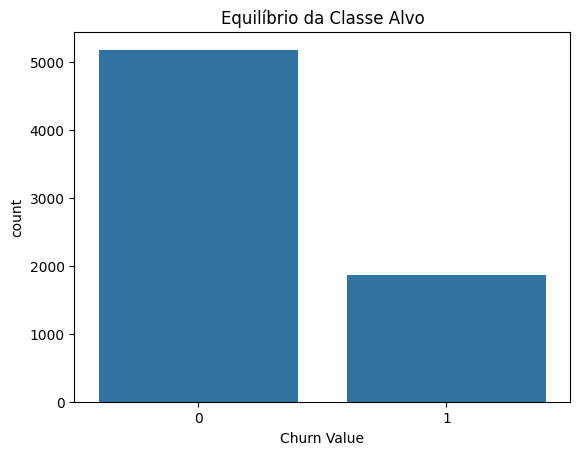

In [26]:
sns.countplot(x='Churn Value', data=df)
plt.title('Equilíbrio da Classe Alvo')
plt.show()

2. Distribuição de Gênero vs Churn

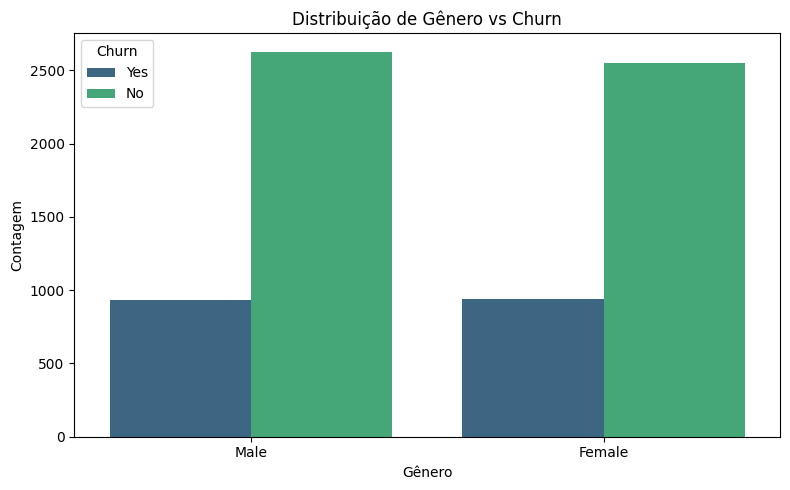

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Churn Label', data=df, palette='viridis')
plt.title('Distribuição de Gênero vs Churn')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

3. Mapa de calor de concentração de cliente por cidade vs Churn

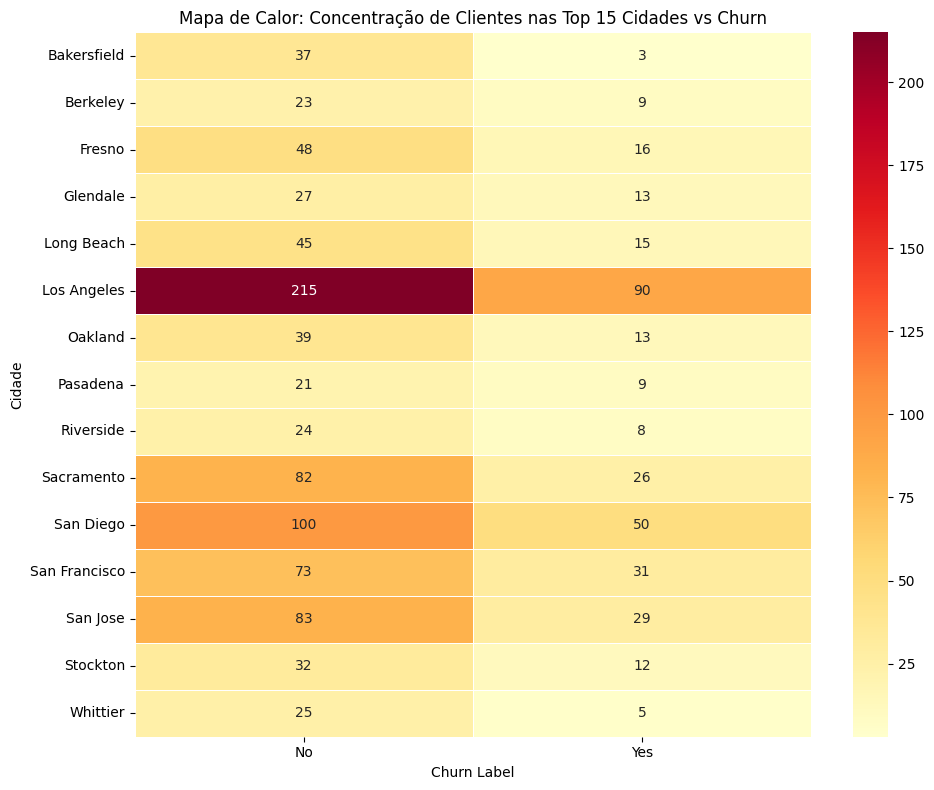

In [28]:
plt.figure(figsize=(10, 8))

# Como Zip Code é muito granular e State costuma ser único (Califórnia),
# vamos focar nas Top 15 Cidades para não poluir o gráfico
top_cities = df['City'].value_counts().head(15).index
df_top_cities = df[df['City'].isin(top_cities)]

# Criar a matriz contendo o cruzamento de Cidade x Churn Label
city_churn_matrix = pd.crosstab(df_top_cities['City'], df_top_cities['Churn Label'])

# Cria um mapa de calor categórico
sns.heatmap(city_churn_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5)

plt.title('Mapa de Calor: Concentração de Clientes nas Top 15 Cidades vs Churn')
plt.xlabel('Churn Label')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()

4. Distribuição de Dependentes Vs Churn

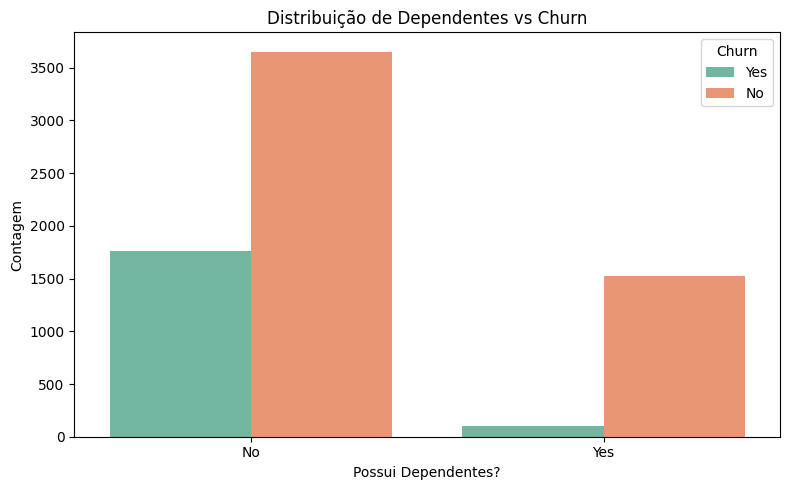

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Dependents', hue='Churn Label', data=df, palette='Set2')
plt.title('Distribuição de Dependentes vs Churn')
plt.xlabel('Possui Dependentes?')
plt.ylabel('Contagem')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

5. Método de Pagamento vs Churn

<Figure size 1000x600 with 0 Axes>

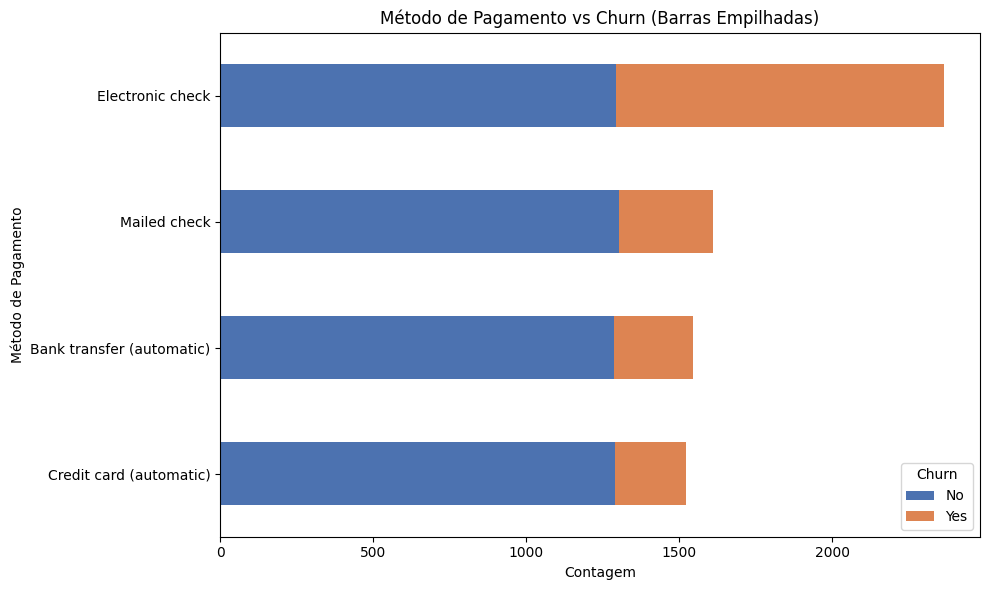

In [30]:
plt.figure(figsize=(10, 6))

# Usando o pandas crosstab para fazer o gráfico empilhado
payment_churn_ct = pd.crosstab(df['Payment Method'], df['Churn Label'])
# Ordena pelo total para melhor visualização
payment_churn_ct['Total'] = payment_churn_ct.sum(axis=1)
payment_churn_ct = payment_churn_ct.sort_values('Total', ascending=True).drop('Total', axis=1)

payment_churn_ct.plot(kind='barh', stacked=True, color=['#4C72B0', '#DD8452'], figsize=(10,6))
plt.title('Método de Pagamento vs Churn (Barras Empilhadas)')
plt.xlabel('Contagem')
plt.ylabel('Método de Pagamento')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Data Readiness

### 1. Limpeza e Tratamento de Tipos de Dados

**O que está sendo feito:** Removendo colunas inúteis como IDs (`CustomerID`) e regiões limitadas (`State`), além de colunas que só existem após o churn (`Churn Label`, `Churn Reason`). Também forçamos a conversão da coluna `Total Charges` para um formato numérico, preenchendo valores vazios ou não declarados com `0` (casos comuns em novos clientes).

**Motivação:** Precisamos retirar o que gera "Data Leakage" (vazamento de dados: dar os motivos do cancelamento e as classificações atuais de devolução se queremos descobrir um evento futuro) que induziria o modelo a trapacear e zerar dados vazios. Como os modelos de ML só engolem números para o cálculo, precisávamos alterar de `object` para `numeric`.

In [31]:
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'Lat Long', 
                'Churn Label', 'Churn Score', 'Churn Reason']

df_clean = df.drop(columns=cols_to_drop)

# Forçar 'Total Charges' para numérico (erros viram NaN) e preencher com 0 (para clientes novos)
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
df_clean['Total Charges'] = df_clean['Total Charges'].fillna(0)

print(f"Colunas restantes ({df_clean.shape[1]}): {df_clean.columns.tolist()}")

Colunas restantes (25): ['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


### 2. Encoding de Variáveis Categóricas

**O que está sendo feito:** Aplicando a técnica de One-Hot Encoding (`pd.get_dummies`) para criar novas colunas numéricas que assumem apenas valor numérico binário (0 ou 1) substituindo as colunas categóricas (como "Male" e "Female", ou "DSL", "Fiber Optic"). Ao final, exportamos tudo através do dataset recém codificado `Telco_customer_churn_ready.csv`.

**Motivação:** Modelos de Machine Learning avaliam todos os dados com base em matemática e equações algébricas. Eles não conseguem ler e interpretar palavras como "Male". Ao utilizar o _Encoding_, representamos exatamente a mesma informação num cenário de chaves binárias para que o modelo consiga decifrar sem problemas lógicos - evitar isso sem atribuir "pesos" que poderiam surgir falsamente caso simplesmente trocássemos para `A=1, B=2, C=3`.

In [33]:
# Separar a variável alvo
X = df_clean.drop('Churn Value', axis=1)
y = df_clean['Churn Value']

# Identificar variáveis categóricas para aplicar o One-Hot Encoding (pd.get_dummies)
cat_cols = X.select_dtypes(include=['object']).columns

# Transforma texto em colunas (0 ou 1) numéricas equivalentes
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"Número de features após o encoding: {X_encoded.shape[1]}")

# Juntar a variável alvo de volta para ter o dataset completo
df_encoded = X_encoded.copy()
df_encoded['Churn Value'] = y

# Salvar o dataset codificado em um novo arquivo CSV para visualização
from pathlib import Path

encoded_csv_path = Path("../data/Telco_customer_churn_ready.csv")
encoded_csv_path.parent.mkdir(parents=True, exist_ok=True)
df_encoded.to_csv(encoded_csv_path, index=False)
print(f"Arquivo codificado salvo em: {encoded_csv_path.resolve()}")

X_encoded.head(3)

Número de features após o encoding: 1162
Arquivo codificado salvo em: D:\Projetos\FIAP\Tech Challenge 01\9mlet-tech-challenge-1-churn-prevision\data\Telco_customer_churn_ready.csv


,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV,City_Acton,City_Adelanto,City_Adin,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,90003,33.964131,-118.272783,2,53.85,108.15,3239,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,90005,34.059281,-118.307420,2,70.70,151.65,2701,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,90006,34.048013,-118.293953,8,99.65,820.50,5372,False,False,False,...,False,True,False,True,False,False,True,False,True,False


### 3. Data Split (Treino e Teste)

**O que está sendo feito:** Dividindo o banco de dados principal em duas vias: 70% de registros históricos reais para criar e ensinar o algoritmo (Treino) e 30% em formato de prova final para testá-lo com dados nunca antes vistos por ele (Teste). Mantemos também uma camada de balança para igualar as vias (`stratify=y`).

**Motivação:** Se treinarmos e aprovarmos a máquina contendo 100% dos exames em mão, nunca saberemos se o modelo genuinamente "aprendeu" a lógica por trás ou simplesmente "decorou" os indivíduos no histórico para prever (chamado de Overfitting em Data Science). O _stratify_ foi adotado para evitar discrepância, como ter dezenas de simule nos testes contra faltivos nos treinos ou vice-versa prejudicando a análise desbalanceada da classe principal.

In [34]:
from sklearn.model_selection import train_test_split

# Dividindo os dados (70% para treino, 30% para teste)
# stratify=y garante que a proporção de Churn seja igual em ambas as bases
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamanho da base de treino: {X_train.shape[0]} linhas.")
print(f"Tamanho da base de teste: {X_test.shape[0]} linhas.")
print("\nDistribuição do Churn no Treino:")
print(y_train.value_counts(normalize=True) * 100)

Tamanho da base de treino: 4930 linhas.
Tamanho da base de teste: 2113 linhas.

Distribuição do Churn no Treino:
Churn Value
0    73.46856
1    26.53144
Name: proportion, dtype: float64
